In [1]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("fivethirtyeight")

In [2]:
df = pd.read_csv("../data/sd254_cards.csv")

In [3]:
df.shape

(6146, 13)

In [4]:
df.head(10)

,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
5,1,0,Visa,Credit,4404898874682993,09/2003,736,YES,1,$27500,09/2003,2012,No
6,1,1,Visa,Debit,4001482973848631,07/2022,972,YES,2,$28508,02/2011,2011,No
7,1,2,Mastercard,Debit,5627220683410948,06/2022,48,YES,2,$9022,07/2003,2015,No
8,1,3,Mastercard,Debit (Prepaid),5711382187309326,11/2020,722,YES,2,$54,06/2010,2015,No
9,1,4,Mastercard,Debit (Prepaid),5766121508358701,02/2023,908,YES,1,$99,07/2006,2012,No


In [5]:
df["Card Brand"].value_counts(dropna=False)

Card Brand
Mastercard    3209
Visa          2326
Amex           402
Discover       209
Name: count, dtype: int64

In [6]:
df["Card Type"].value_counts(dropna=False)

Card Type
Debit              3511
Credit             2057
Debit (Prepaid)     578
Name: count, dtype: int64

In [7]:
df["Has Chip"].value_counts(dropna=False)

Has Chip
YES    5500
NO      646
Name: count, dtype: int64

In [8]:
df["limit"] = df["Credit Limit"].str.replace("$", "").astype("float")

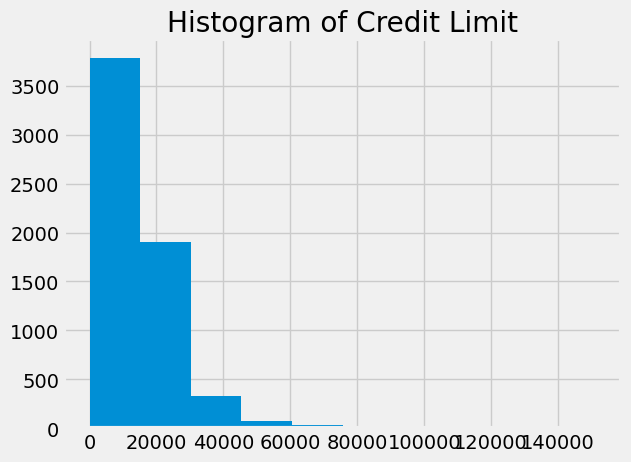

In [9]:
plt.hist(df["limit"])
plt.title("Histogram of Credit Limit");

In [10]:
df["Card on Dark Web"].value_counts(dropna=False)

Card on Dark Web
No    6146
Name: count, dtype: int64

In [11]:
df["age"] = 2026 - df["Acct Open Date"].str[-4:].astype(int)

In [12]:
df["limit_quartile"] = pd.qcut(df["limit"], 4)
df["age_quartile"] = pd.qcut(df["age"], 4)

In [13]:
df

,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web,limit,age,limit_quartile,age_quartile
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No,24295.0,24,"(19156.5, 151223.0]","(20.0, 35.0]"
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No,21968.0,12,"(19156.5, 151223.0]","(10.0, 16.0]"
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No,46414.0,23,"(19156.5, 151223.0]","(20.0, 35.0]"
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No,12400.0,23,"(7042.75, 12592.5]","(20.0, 35.0]"
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No,28.0,18,"(-0.001, 7042.75]","(16.0, 20.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,1997,1,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No,6900.0,26,"(-0.001, 7042.75]","(20.0, 35.0]"
6142,1997,2,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No,5700.0,14,"(-0.001, 7042.75]","(10.0, 16.0]"
6143,1998,0,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No,9200.0,14,"(7042.75, 12592.5]","(10.0, 16.0]"
6144,1999,0,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No,28074.0,6,"(19156.5, 151223.0]","(5.999, 10.0]"
